In [1]:
import numpy as np

In [23]:
class Perceptron:
    # Attributes
    # -----------
    # w_ : 1d-array
    # Weights after fitting.
    # b_ : Scalar
    # Bias unit after fitting.
    # errors_ : list
    # Number of misclassifications (updates) in each epoch.

    def __init__(self, lr=0.01, epochs=50, random_state=1) -> None:
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.0)

        self.errors_ = []

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.lr * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update

                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)  # activation function

----

In [2]:
import os
import pandas as pd

In [ ]:
s = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
print("From URL: ", s)

From URL:  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


In [ ]:
df = pd.read_csv(s, header=None, encoding="utf-8")
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
import matplotlib.pyplot as plt

In [ ]:
# Select setosa and versicolor
y = df.iloc[0:100, -1].values
y = np.where(y == "Iris-setosa", 0, 1)

In [ ]:
# Extract sepal and peta length
X = df.iloc[0:100, [0, 2]].values

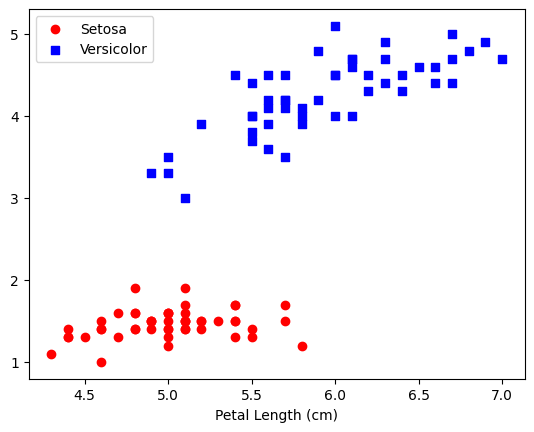

In [ ]:
plt.scatter(X[:50, 0], X[:50, 1], color="red", marker="o", label="Setosa")
plt.scatter(X[50:, 0], X[50:, 1], color="blue", marker="s", label="Versicolor")

plt.xlabel("Sepal Length (cm)")
plt.xlabel("Petal Length (cm)")
plt.legend(loc="upper left")
plt.show()

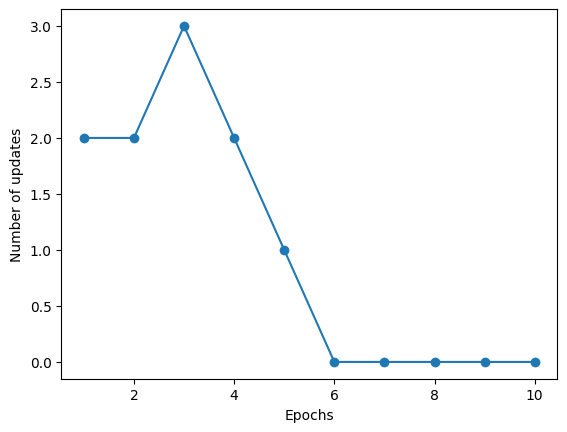

In [24]:
ppn = Perceptron(lr=0.1, epochs=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Number of updates")
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, resolution=0.02):

    markers = ("o", "s", "^", "v", "<")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[: len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)
    )

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)  # labels
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmpa=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black",
        )

/tmp/ipykernel_54899/1069884148.py:20: UserWarning: The following kwargs were not used by contour: 'cmpa'
  plt.contourf(xx1, xx2, lab, alpha=0.3, cmpa=cmap)


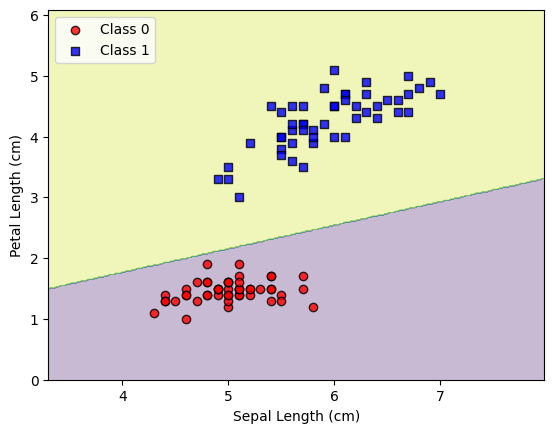

In [ ]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend(loc="upper left")
plt.show()

---
### Implementing Adaline

In [ ]:
class AdalineGD:  # Batch Gradient Descent
    def __init__(self, lr=0.01, epochs=50, random_state=1) -> None:
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.0)

        self.losses_ = []

        for _ in range(self.epochs):
            net_input = self.net_input(X)
            output = self.activation(net_input)

            errors = y - output
            self.w_ += self.lr * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.lr * 2.0 * errors.mean()

            loss = (errors**2).mean()
            self.losses_.append(loss)

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.5, 1, 0)

    def activation(self, X):
        return X

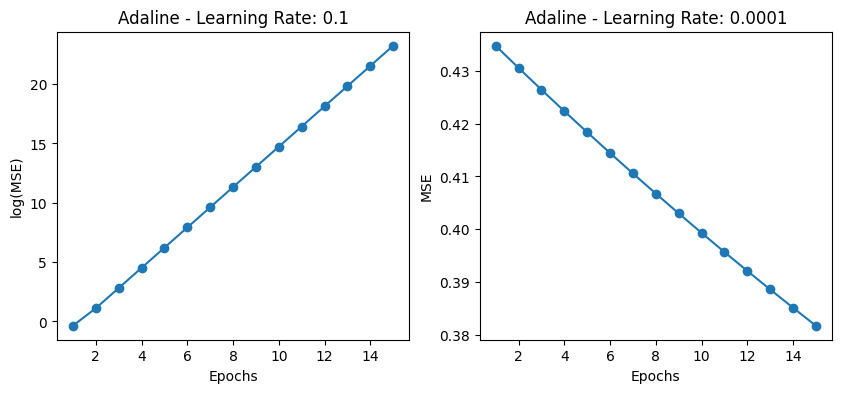

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ada1 = AdalineGD(epochs=15, lr=0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.losses_) + 1), np.log10(ada1.losses_), marker="o")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("log(MSE)")
ax[0].set_title("Adaline - Learning Rate: 0.1")

ada2 = AdalineGD(epochs=15, lr=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.losses_) + 1), (ada2.losses_), marker="o")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("MSE")
ax[1].set_title("Adaline - Learning Rate: 0.0001")

plt.show()

In [32]:
X_std = np.copy(X)
X_std[:, 0] = (X_std[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X_std[:, 1] - X[:, 1].mean()) / X[:, 1].std()

In [33]:
ada_gd = AdalineGD(lr=0.5, epochs=20)
ada_gd.fit(X_std, y)

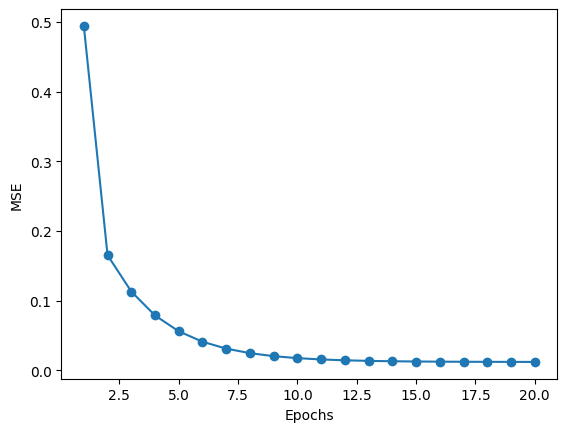

/tmp/ipykernel_54899/1069884148.py:20: UserWarning: The following kwargs were not used by contour: 'cmpa'
  plt.contourf(xx1, xx2, lab, alpha=0.3, cmpa=cmap)


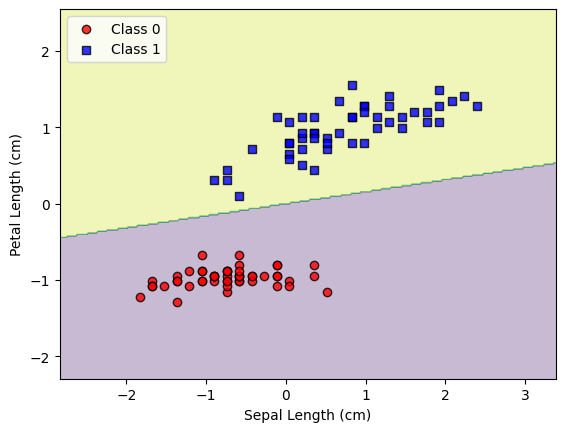

In [35]:
plt.plot(range(1, len(ada_gd.losses_) + 1), (ada_gd.losses_), marker="o")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend(loc="upper left")
plt.show()

---
### AdaLine Stochastic GD

In [41]:
class AdalineSGD:
    def __init__(self, lr=0.01, epochs=50, shuffle=True, random_state=None) -> None:
        self.lr = lr
        self.epochs = epochs
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data"""

        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for _ in range(self.epochs):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)

    def _shuffle(self, X, y):
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float_(0.0)

        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = target - output
        self.w_ += self.lr * 2.0 * xi * (error)
        self.b_ += self.lr * 2.0 * error
        loss = error**2

        return loss

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.5, 1, 0)

    def activation(self, X):
        return X

In [ ]:
ada_sgd = AdalineSGD(epochs=15, lr=0.01, random_state=1)
ada_sgd.fit(X_std, y)

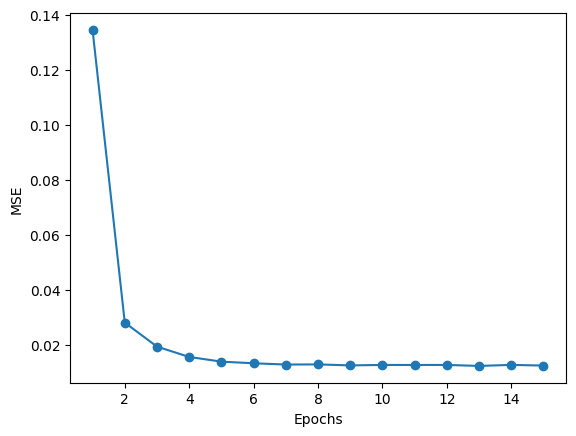

/tmp/ipykernel_54899/1069884148.py:20: UserWarning: The following kwargs were not used by contour: 'cmpa'
  plt.contourf(xx1, xx2, lab, alpha=0.3, cmpa=cmap)


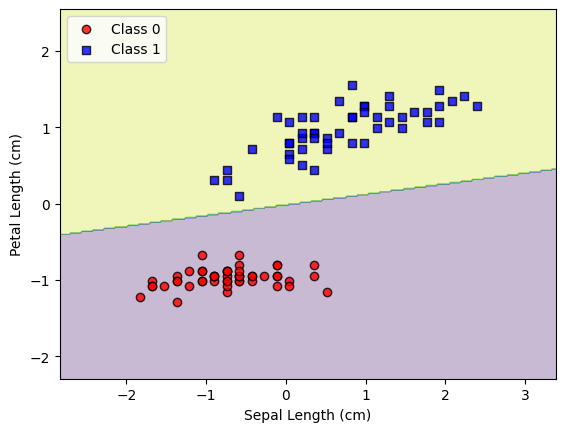

In [43]:
plt.plot(range(1, len(ada_sgd.losses_) + 1), (ada_sgd.losses_), marker="o")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend(loc="upper left")
plt.show()